<h1> Polynomial Regression </h1>

Polynomial Regression = Linear Regression + Feature Transformation

Why is it still linear?

Because linearity applies to the parameters, not the features.

The idea behind Polynomial Regression is to create new features:

$$ x,\quad x^2,\quad x^3,\dots $$

Then, we still use standard Linear Regression:

$$ \hat y = w_1x+w_2x^2+w_3x^3+b $$

So, a crucial point:

In terms of modeling, Polynomial Regression is still a linear model because it is linear with respect to the parameters $w_i$; we have simply made the feature space non-linear.

We can also create interaction terms for multiple features. For instance, if:

$$ X=[x_1,x_2] $$

and the degree is 2, the features become:

$$ x_1,\ x_2,\ x_1^2,\ x_1x_2,\ x_2^2 $$

The $x_1x_2$ term is significant because it allows the model to capture interactions between the features.

For this notebook, we’ll start with a simple synthetic dataset to clearly illustrate the concept of polynomial regression, and then test it on the California Housing dataset. This is better than jumping straight to a large dataset, where the effect of the degree might get lost.

#### Polynomial Regression

1. Why Linear Regression Can Fail
2. Polynomial Feature Expansion
3. Mathematical Formulation
4. From-Scratch Polynomial Feature Generator
5. Synthetic Nonlinear Experiment
6. Effect of Polynomial Degree
7. Overfitting and Underfitting
8. California Housing Experiment
9. Scikit-Learn Comparison
10. Summary

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.linear_regression import LinearRegressionGD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from src.polynomial_regression import PolynomialFeatures

<h3> Step 1: Creating a Synthetic Dataset </h3>

We also generate an array of random noise with a normal distribution (Gaussian noise).

The parameters are:

0 → mean of the normal distribution</br>
2 → standard deviation</br>
size=X.shape → the output has the exact same dimensions as X

This means the noise values ​​are drawn from this distribution:

$$ \mathcal{N}(0, 2^2) $$

Thus, most values ​​are close to zero, but they have a spread defined by a standard deviation of 2.

In other words, we add noise to the original data to make it slightly less ideal and more representative of real-world data.

In [140]:
np.random.seed(42)

X = np.linspace(
    -3,
    3,
    100
)

noise = np.random.normal(
    0,
    2,
    size=X.shape
)

y = (
    2 * X**2
    + 3 * X
    + 5
    + noise
)

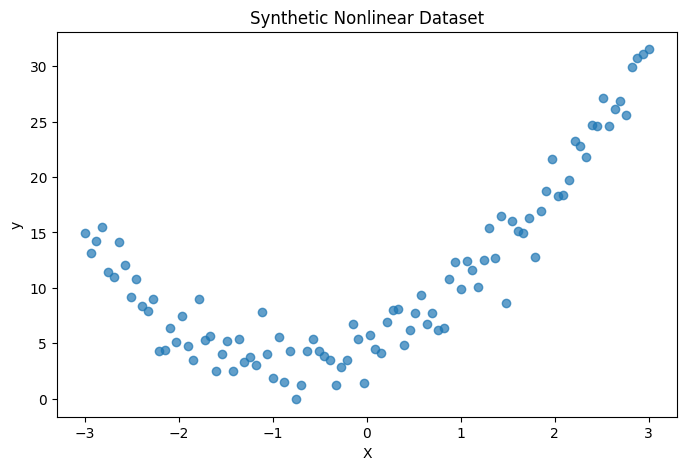

In [141]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    alpha=0.7
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Nonlinear Dataset")

plt.show()

In [142]:
X.shape

(100,)

If we apply simple linear regression to this data, it yields a straight line and loses a significant portion of the data's structure.

<h3> Step 2: Simple Linear Regression Test </h3>

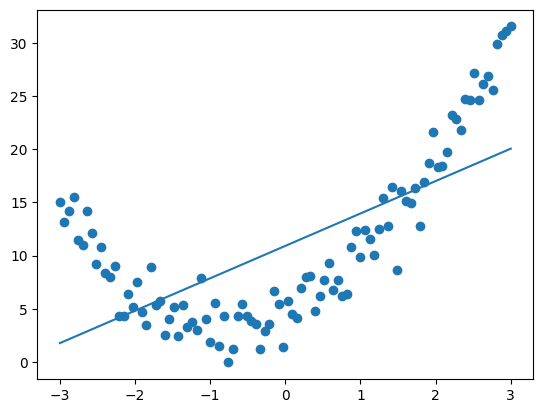

In [143]:
X_linear = X.reshape(
    -1,
    1
)

linear_model = LinearRegressionGD(
    learning_rate=0.01,
    epochs=1000
)

linear_model.fit(
    X_linear,
    y
)

y_pred_linear = linear_model.predict(
    X_linear
)

plt.scatter(
    X,
    y
)
plt.plot(
    X,
    y_pred_linear
)
plt.show()

In [144]:
X_linear.shape

(100, 1)

<h3> Step 3: Manually Creating Polynomial Features </h3>

In libraries like `sklearn`, `PolynomialFeatures()` is somewhat more complex.

This is because it must handle various scenarios:

Multiple features

Multiple degrees

Interaction features

For instance, if:

$$ X=[x_1,x_2] $$

and the degree is 2, the result isn't just:

$$ [x_1,x_2,x_1^2,x_2^2] $$

Instead, the following must also be generated:

$$ [x_1,x_2,x_1^2,x_1x_2,x_2^2] $$

For now, we will implement a simple single-feature version to ensure the concept is clearly understood.

In [145]:
poly = PolynomialFeatures(
    degree=2
)

X_poly = poly.transform(
    X_linear
)

print(X_poly.shape)

(100, 2)


In [146]:
poly_model = LinearRegressionGD(
    learning_rate=0.001,
    epochs=5000
)

poly_model.fit(
    X_poly,
    y
)

y_pred_poly = poly_model.predict(
    X_poly
)

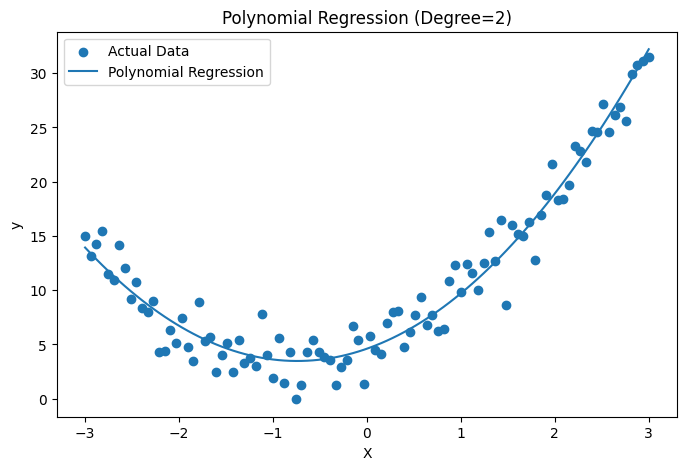

In [147]:
plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    y_pred_poly,
    label="Polynomial Regression"
)

plt.xlabel("X")
plt.ylabel("y")

plt.title(
    "Polynomial Regression (Degree=2)"
)

plt.legend()
plt.show()

<h3> Step 4: Underfitting and Overfitting Effect </h3>

In [148]:
X_train, X_test, y_train, y_test = train_test_split(
    X_linear,
    y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(70, 1)
(30, 1)


In [149]:
degrees = [
    1,
    2,
    3,
    5,
    10
]

train_errors = []
test_errors = []

In [150]:
for degree in degrees:

    print(f"Degree: {degree}")

    # Polynomial transformation
    poly = PolynomialFeatures(
        degree=degree
    )

    X_train_poly = poly.transform(
        X_train
    )

    X_test_poly = poly.transform(
        X_test
    )

    scaler = StandardScaler()

    X_train_poly_scaled = scaler.fit_transform(
        X_train_poly
    )


    X_test_poly_scaled = scaler.transform(
        X_test_poly
    )

    # Model
    model = LinearRegressionGD(
        learning_rate=0.00001,
        epochs=10000
    )

    # only Train
    model.fit(
        X_train_poly_scaled,
        y_train
    )

    # Prediction on Train
    y_train_pred = model.predict(
        X_train_poly_scaled
    )

    # Prediction on Test
    y_test_pred = model.predict(
        X_test_poly_scaled
    )

    print("Degree:", degree)

    print(
        "Train prediction NaN:",
        np.isnan(y_train_pred).sum()
    )

    print(
        "Test prediction NaN:",
        np.isnan(y_test_pred).sum()
    )

    # Error calculation
    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    train_errors.append(
        train_mse
    )

    test_errors.append(
        test_mse
    )

    print(
        "Train MSE:",
        train_mse
    )
    print(
        "Test MSE:",
        test_mse
    )
    print("----------------")

Degree: 1
Degree: 1
Train prediction NaN: 0
Test prediction NaN: 0
Train MSE: 141.09973611226704
Test MSE: 113.85268089095948
----------------
Degree: 2
Degree: 2
Train prediction NaN: 0
Test prediction NaN: 0
Train MSE: 129.23491832448676
Test MSE: 106.33335429883235
----------------
Degree: 3
Degree: 3
Train prediction NaN: 0
Test prediction NaN: 0
Train MSE: 123.48412814530225
Test MSE: 105.19013083373994
----------------
Degree: 5
Degree: 5
Train prediction NaN: 0
Test prediction NaN: 0
Train MSE: 113.30160049264516
Test MSE: 102.43028849209732
----------------
Degree: 10
Degree: 10
Train prediction NaN: 0
Test prediction NaN: 0
Train MSE: 104.43245497974769
Test MSE: 103.00653422351313
----------------


In [151]:
results = pd.DataFrame(
    {
        "Degree": degrees,
        "Train MSE": train_errors,
        "Test MSE": test_errors
    }
)

results

,Degree,Train MSE,Test MSE
0,1,141.099736,113.852681
1,2,129.234918,106.333354
2,3,123.484128,105.190131
3,5,113.301600,102.430288
4,10,104.432455,103.006534


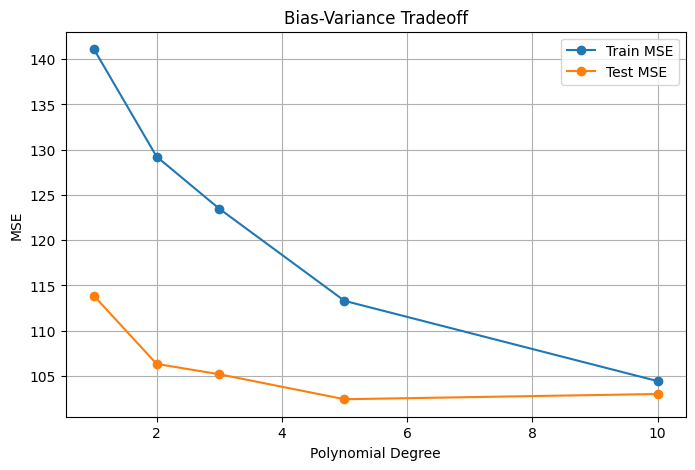

In [152]:
plt.figure(figsize=(8,5))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Train MSE"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xlabel(
    "Polynomial Degree"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Bias-Variance Tradeoff"
)

plt.legend()
plt.grid()
plt.show()

#### Effect of Polynomial Degree

Increasing the polynomial degree increases model complexity.

Low-degree models have high bias and cannot capture the nonlinear pattern, resulting in underfitting.

As the degree increases, the model becomes more flexible and training error decreases.

However, very high degrees may cause overfitting, where the model learns noise instead of the underlying pattern.

The optimal degree provides a balance between bias and variance, achieving good generalization on unseen data.

#### Bias-Variance Tradeoff

The polynomial degree controls the complexity of the model.

Low-degree polynomial models have limited flexibility and cannot capture the nonlinear structure of the data, resulting in high bias and underfitting.

Increasing the degree reduces bias by allowing the model to learn more complex patterns. However, very high-degree models may increase variance and memorize noise instead of learning the underlying relationship.

The optimal model complexity is achieved when the model balances bias and variance and provides good performance on unseen data.

<h3> Step 5: More Complex Experiment </h3>

Part 1: LR = 0.00001

In [153]:
np.random.seed(42)

X = np.linspace(-3,3,40)

noise = np.random.normal(
    0,
    5,
    size=X.shape
)

y = (
    2 * X**2
    + 3 * X
    + 5
    + noise
)

X_linear = X.reshape(
    -1,
    1
)

X_train, X_test, y_train, y_test = train_test_split(
    X_linear,
    y,
    test_size=0.3,
    random_state=42
)

In [154]:
degrees = [
    1,
    2,
    5,
    10,
    15,
    20
]

train_errors = []
test_errors = []

In [155]:
for degree in degrees:

    print(f"Degree: {degree}")

    # Polynomial transformation
    poly = PolynomialFeatures(
        degree=degree
    )

    X_train_poly = poly.transform(
        X_train
    )

    X_test_poly = poly.transform(
        X_test
    )

    scaler = StandardScaler()

    X_train_poly_scaled = scaler.fit_transform(
        X_train_poly
    )

    X_test_poly_scaled = scaler.transform(
        X_test_poly
    )

    # Model
    model = LinearRegressionGD(
        learning_rate=0.00001,
        epochs=10000
    )

    # This is the only place where the model learns something.
    # only Train
    model.fit(
        X_train_poly_scaled,
        y_train
    )

    # Prediction on Train
    y_train_pred = model.predict(
        X_train_poly_scaled
    )

    # Prediction on Test
    y_test_pred = model.predict(
        X_test_poly_scaled
    )

    # Error calculation
    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    train_errors.append(
        train_mse
    )

    test_errors.append(
        test_mse
    )

    print(
        "Train MSE:",
        train_mse
    )
    print(
        "Test MSE:",
        test_mse
    )
    print("----------------")

Degree: 1
Train MSE: 146.42530680589746
Test MSE: 135.21886826009307
----------------
Degree: 2
Train MSE: 134.92936758345078
Test MSE: 121.80469521607957
----------------
Degree: 5
Train MSE: 127.2144037090109
Test MSE: 104.43809807114445
----------------
Degree: 10
Train MSE: 122.33566334668403
Test MSE: 86.22005006474842
----------------
Degree: 15
Train MSE: 122.05224792781425
Test MSE: 79.06458317440331
----------------
Degree: 20
Train MSE: 122.23157599064372
Test MSE: 73.83936429164365
----------------


In [156]:
results = pd.DataFrame(
    {
        "Degree": degrees,
        "Train MSE": train_errors,
        "Test MSE": test_errors
    }
)

results

,Degree,Train MSE,Test MSE
0,1,146.425307,135.218868
1,2,134.929368,121.804695
2,5,127.214404,104.438098
3,10,122.335663,86.220050
4,15,122.052248,79.064583
5,20,122.231576,73.839364


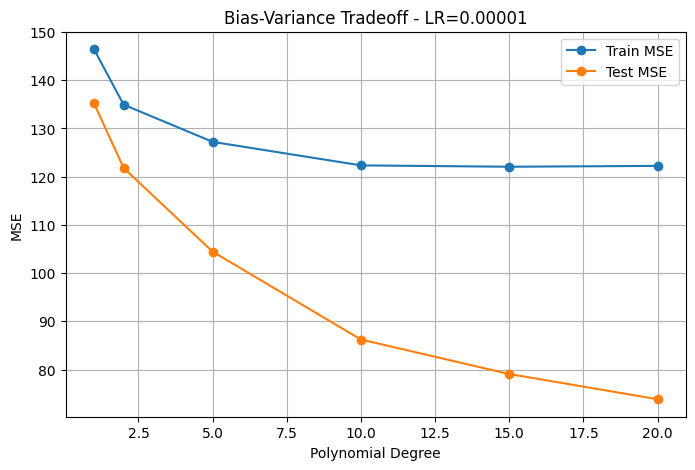

In [157]:
plt.figure(figsize=(8,5))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Train MSE"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xlabel(
    "Polynomial Degree"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Bias-Variance Tradeoff - LR=0.00001"
)

plt.legend()
plt.grid()
plt.show()

Part 2: LR = 0.0001

In [158]:
np.random.seed(42)

X = np.linspace(-3,3,40)

noise = np.random.normal(
    0,
    5,
    size=X.shape
)

y = (
    2 * X**2
    + 3 * X
    + 5
    + noise
)

X_linear = X.reshape(
    -1,
    1
)

X_train, X_test, y_train, y_test = train_test_split(
    X_linear,
    y,
    test_size=0.3,
    random_state=42
)

In [159]:
degrees = [
    1,
    2,
    5,
    10,
    15,
    20
]

train_errors = []
test_errors = []

In [160]:
for degree in degrees:

    print(f"Degree: {degree}")

    # Polynomial transformation
    poly = PolynomialFeatures(
        degree=degree
    )

    X_train_poly = poly.transform(
        X_train
    )

    X_test_poly = poly.transform(
        X_test
    )

    scaler = StandardScaler()

    X_train_poly_scaled = scaler.fit_transform(
        X_train_poly
    )

    X_test_poly_scaled = scaler.transform(
        X_test_poly
    )

    # Model
    model = LinearRegressionGD(
        learning_rate=0.0001,
        epochs=10000
    )

    # This is the only place where the model learns something.
    # only Train
    model.fit(
        X_train_poly_scaled,
        y_train
    )

    # Prediction on Train
    y_train_pred = model.predict(
        X_train_poly_scaled
    )

    # Prediction on Test
    y_test_pred = model.predict(
        X_test_poly_scaled
    )

    # Error calculation
    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    train_errors.append(
        train_mse
    )

    test_errors.append(
        test_mse
    )

    print(
        "Train MSE:",
        train_mse
    )
    print(
        "Test MSE:",
        test_mse
    )
    print("----------------")

Degree: 1
Train MSE: 63.93726362298029
Test MSE: 64.76937377572233
----------------
Degree: 2
Train MSE: 24.26735704970687
Test MSE: 19.921381386822837
----------------
Degree: 5
Train MSE: 25.996471894739674
Test MSE: 21.690560594892144
----------------
Degree: 10
Train MSE: 26.96599731073039
Test MSE: 22.22049532790595
----------------
Degree: 15
Train MSE: 25.827100022738144
Test MSE: 24.137166573134568
----------------
Degree: 20
Train MSE: 24.873838348876934
Test MSE: 31.241564046387577
----------------


In [161]:
results = pd.DataFrame(
    {
        "Degree": degrees,
        "Train MSE": train_errors,
        "Test MSE": test_errors
    }
)

results

,Degree,Train MSE,Test MSE
0,1,63.937264,64.769374
1,2,24.267357,19.921381
2,5,25.996472,21.690561
3,10,26.965997,22.220495
4,15,25.827100,24.137167
5,20,24.873838,31.241564


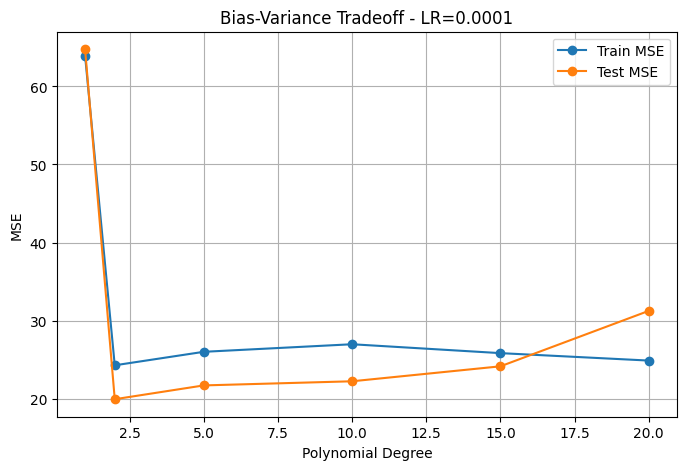

In [162]:
plt.figure(figsize=(8,5))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Train MSE"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xlabel(
    "Polynomial Degree"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Bias-Variance Tradeoff - LR=0.0001"
)

plt.legend()
plt.grid()
plt.show()

Part 3: LR = 0.001

In [163]:
np.random.seed(42)

X = np.linspace(-3,3,40)

noise = np.random.normal(
    0,
    5,
    size=X.shape
)

y = (
    2 * X**2
    + 3 * X
    + 5
    + noise
)

X_linear = X.reshape(
    -1,
    1
)

X_train, X_test, y_train, y_test = train_test_split(
    X_linear,
    y,
    test_size=0.3,
    random_state=42
)

In [164]:
degrees = [
    1,
    2,
    5,
    10,
    15,
    20
]

train_errors = []
test_errors = []

In [165]:
for degree in degrees:

    print(f"Degree: {degree}")

    # Polynomial transformation
    poly = PolynomialFeatures(
        degree=degree
    )

    X_train_poly = poly.transform(
        X_train
    )

    X_test_poly = poly.transform(
        X_test
    )

    scaler = StandardScaler()

    X_train_poly_scaled = scaler.fit_transform(
        X_train_poly
    )

    X_test_poly_scaled = scaler.transform(
        X_test_poly
    )

    # Model
    model = LinearRegressionGD(
        learning_rate=0.001,
        epochs=10000
    )

    # This is the only place where the model learns something.
    # only Train
    model.fit(
        X_train_poly_scaled,
        y_train
    )

    # Prediction on Train
    y_train_pred = model.predict(
        X_train_poly_scaled
    )

    # Prediction on Test
    y_test_pred = model.predict(
        X_test_poly_scaled
    )

    # Error calculation
    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    train_errors.append(
        train_mse
    )

    test_errors.append(
        test_mse
    )

    print(
        "Train MSE:",
        train_mse
    )
    print(
        "Test MSE:",
        test_mse
    )
    print("----------------")

Degree: 1
Train MSE: 61.621012154276464
Test MSE: 64.70573062989887
----------------
Degree: 2
Train MSE: 20.439665684998623
Test MSE: 19.78729162337818
----------------
Degree: 5
Train MSE: 18.774150803722538
Test MSE: 22.45486569641105
----------------
Degree: 10
Train MSE: 17.30170455496144
Test MSE: 35.02517033458252
----------------
Degree: 15
Train MSE: 17.440233286815126
Test MSE: 40.898106975168226
----------------
Degree: 20
Train MSE: 17.519744737811163
Test MSE: 44.38367270791668
----------------


In [166]:
results = pd.DataFrame(
    {
        "Degree": degrees,
        "Train MSE": train_errors,
        "Test MSE": test_errors
    }
)

results

,Degree,Train MSE,Test MSE
0,1,61.621012,64.705731
1,2,20.439666,19.787292
2,5,18.774151,22.454866
3,10,17.301705,35.025170
4,15,17.440233,40.898107
5,20,17.519745,44.383673


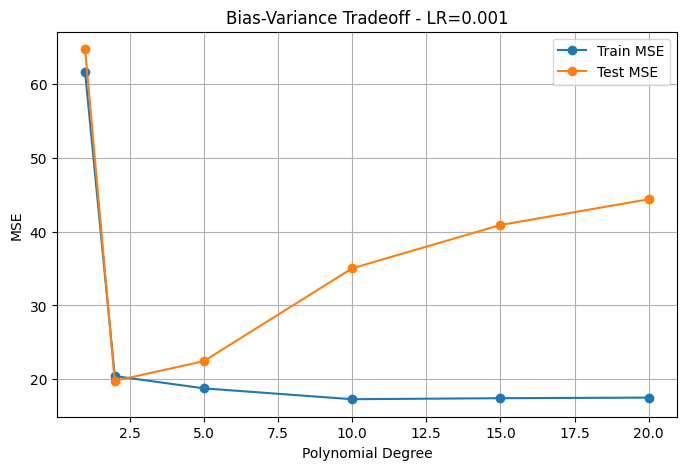

In [168]:
plt.figure(figsize=(8,5))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Train MSE"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xlabel(
    "Polynomial Degree"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Bias-Variance Tradeoff - LR=0.001"
)

plt.legend()
plt.grid()
plt.show()

### Comparison of the behavior of three learning rates


| Learning Rate | behavior                                         |
| ------------- | --------------------------------------------- |
| 0.00001       | The model learns slowly, and overfitting is masked. |
| 0.0001        | Good balance; onset of overfitting at high degrees. |
| 0.001         | Rapid learning, more pronounced overfitting. |


### Effect of Learning Rate on Bias-Variance Tradeoff

The learning rate controls how effectively Gradient Descent optimizes the model parameters.

With a very small learning rate, the optimization process is slow and the model may not fully exploit the complexity of high-degree polynomial features, which can hide overfitting behavior.

As the learning rate increases, the model converges faster and the effect of polynomial complexity becomes clearer. Higher-degree models achieve lower training error but may show increasing test error, indicating higher variance and overfitting.

Therefore, proper optimization is necessary to correctly analyze the bias-variance tradeoff.

This experiment demonstrates that:

Overfitting depends not only on the model but also on the training process.

This is precisely why, in real-world projects, we use:

Learning Rate Scheduling</br>
Early Stopping</br>
Cross-Validation</br>
Regularization